# Aadhaar Migration Analytics – UIDAI Data Hackathon 2026  
### Prepared by: Aryan Singh  


## 1. Problem Statement
Internal migration in India is challenging to measure in real time.
Aadhaar update patterns offer a live signal of population mobility.
This analysis extracts migration flows using UIDAI enrolment and update data.


## 2. Objectives
- Identify migration-receiving states and districts  
- Identify migration-sending regions  
- Separate job-driven vs family migration  
- Detect seasonal migration peaks  
- Forecast Aadhaar update demand  
- Recommend UIDAI resource planning actions  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


In [3]:
df_enrol = pd.read_csv(r"D:\UIDAI COMPETITION\\clean_data\enrolment_merged.csv")
df_demo  = pd.read_csv(r"D:\UIDAI COMPETITION\\clean_data\demographic_merged.csv")
df_bio   = pd.read_csv(r"D:\UIDAI COMPETITION\\clean_data\biometric_merged.csv")

print("Data Loaded")


Data Loaded


In [4]:
for df in [df_enrol, df_demo, df_bio]:
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df['month'] = df['date'].dt.to_period('M')


## 3. Methodology
- Load and merge files
- Convert dates to monthly periods
- Aggregate demographic and enrolment values
- Create migration index
- Compare state and district levels
- Segment by age
- Analyse season trends
- Forecast demand


In [5]:
enrol_month = df_enrol.groupby(['state','district','month'])[['age_0_5','age_5_17','age_18_greater']].sum().reset_index()
enrol_month['total_enrol'] = enrol_month[['age_0_5','age_5_17','age_18_greater']].sum(axis=1)

demo_month = df_demo.groupby(['state','district','month'])[['demo_age_5_17','demo_age_17_']].sum().reset_index()
demo_month['total_demo'] = demo_month[['demo_age_5_17','demo_age_17_']].sum(axis=1)


In [6]:
migration_df = demo_month.merge(
    enrol_month[['state','district','month','total_enrol']],
    on=['state','district','month'],
    how='left'
)

migration_df['migration_index'] = migration_df['total_demo'] / migration_df['total_enrol']


## 4. State-Level Migration Analysis


In [7]:
state_summary = migration_df.groupby('state')['migration_index'].mean().reset_index()

top_receivers = state_summary.sort_values('migration_index', ascending=False).head(10)
top_senders   = state_summary.sort_values('migration_index').head(10)

top_receivers


,state,migration_index
14,Daman & Diu,40.708333
17,Delhi,31.734279
33,Manipur,27.046568
32,Maharashtra,25.814889
8,Chandigarh,25.591156
55,WESTBENGAL,21.000000
61,Westbengal,19.500000
7,Bihar,18.389381
46,Rajasthan,18.097513
13,Dadra and Nagar Haveli and Daman and Diu,17.592596


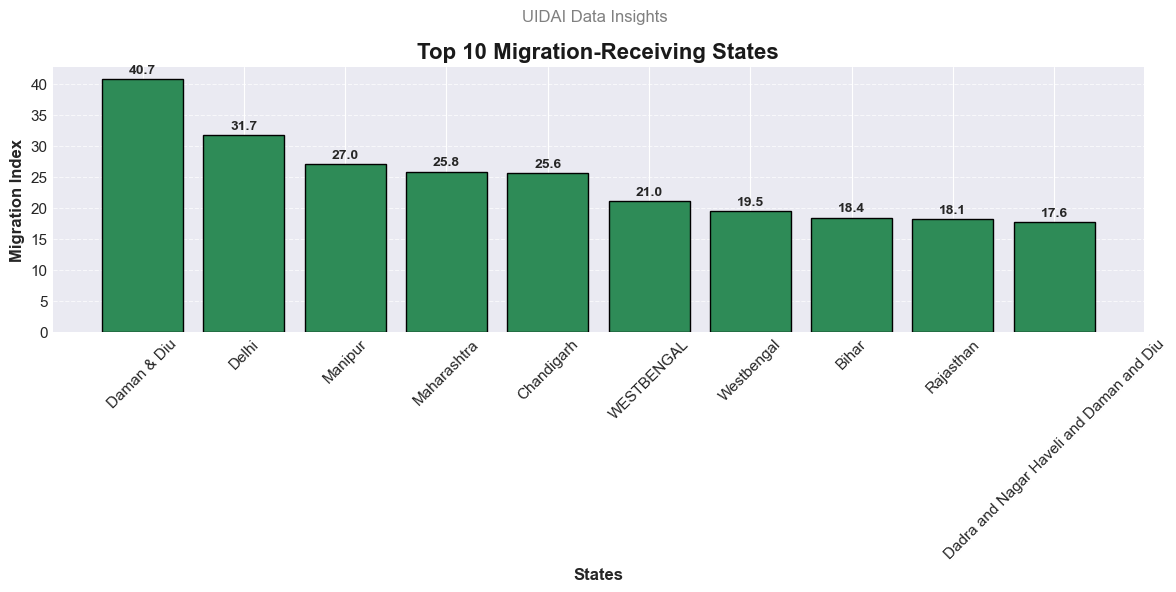

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.style.use("seaborn-v0_8-darkgrid")

bars = plt.bar(
    top_receivers['state'], 
    top_receivers['migration_index'], 
    color='#2E8B57', 
    edgecolor='black'
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.5, 
        f"{yval:.1f}", 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.xticks(rotation=45, fontsize=11, fontweight='medium')
plt.yticks(fontsize=11)
plt.ylabel("Migration Index", fontsize=12, fontweight='bold')
plt.xlabel("States", fontsize=12, fontweight='bold')

plt.title("Top 10 Migration-Receiving States", fontsize=16, fontweight='bold', color='#1a1a1a')
plt.suptitle("UIDAI Data Insights", fontsize=12, color='gray')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

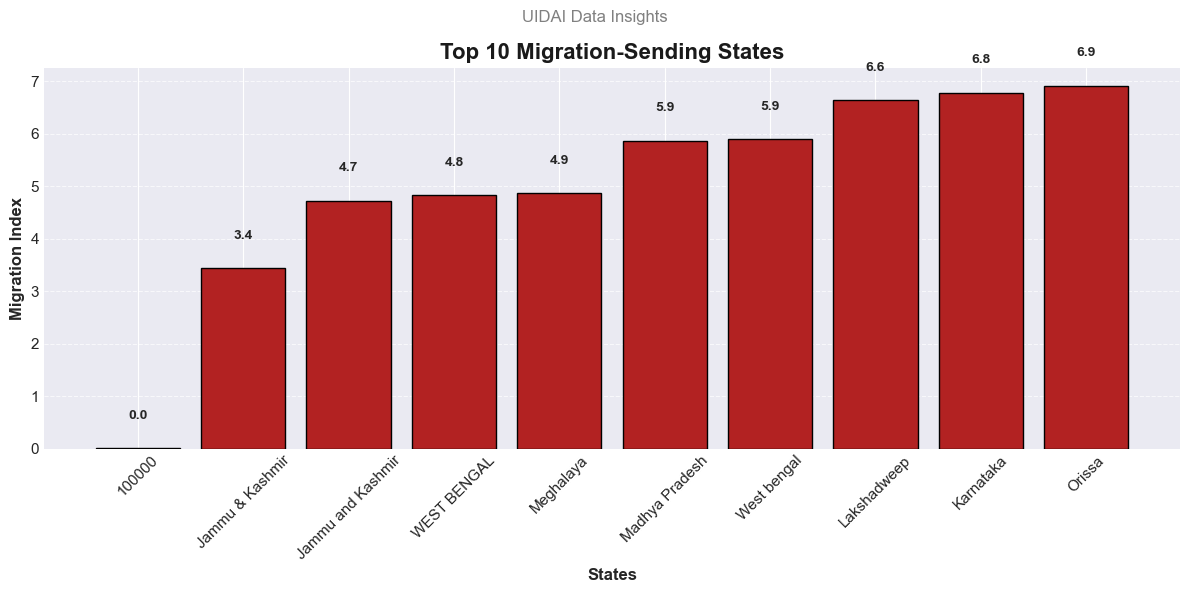

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.style.use("seaborn-v0_8-darkgrid")

bars = plt.bar(
    top_senders['state'], 
    top_senders['migration_index'], 
    color='#B22222', 
    edgecolor='black'
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.5, 
        f"{yval:.1f}", 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.xticks(rotation=45, fontsize=11, fontweight='medium')
plt.yticks(fontsize=11)
plt.ylabel("Migration Index", fontsize=12, fontweight='bold')
plt.xlabel("States", fontsize=12, fontweight='bold')

plt.title("Top 10 Migration-Sending States", fontsize=16, fontweight='bold', color='#1a1a1a')
plt.suptitle("UIDAI Data Insights", fontsize=12, color='gray')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. District-Level Hotspots


In [11]:
district_summary = migration_df.groupby(['state','district'])['migration_index'].mean().reset_index()

top_districts = district_summary.sort_values('migration_index', ascending=False).head(20)
bottom_districts = district_summary.sort_values('migration_index').head(20)

top_districts


,state,district,migration_index
749,Rajasthan,Beawar,449.000000
769,Rajasthan,Jalore,384.000000
762,Rajasthan,Didwana-Kuchaman,308.000000
515,Maharashtra,Ahilyanagar,186.000000
563,Maharashtra,Thane,185.716841
934,Uttar Pradesh,Gorakhpur,169.909337
222,Delhi,North West Delhi,149.666466
141,Bihar,Muzaffarpur,135.716791
783,Rajasthan,Salumbar,127.000000
145,Bihar,Patna,126.208701


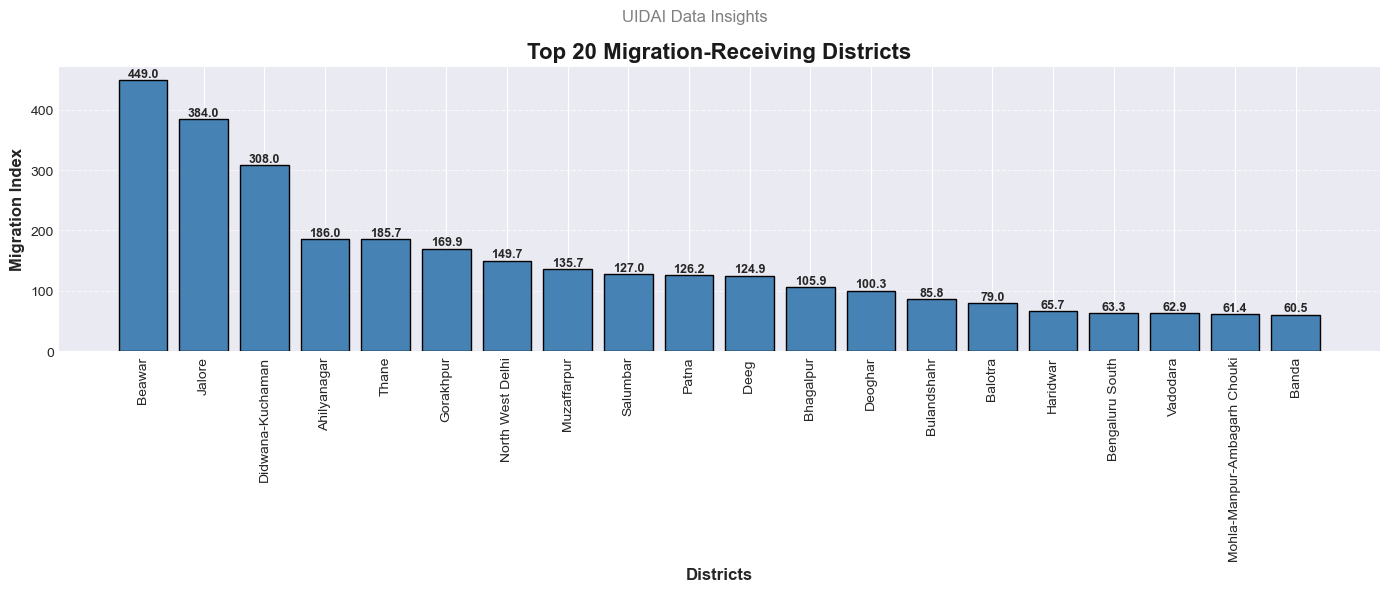

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.style.use("seaborn-v0_8-darkgrid")

bars = plt.bar(
    top_districts['district'], 
    top_districts['migration_index'], 
    color='#4682B4', 
    edgecolor='black'
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.5, 
        f"{yval:.1f}", 
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.xticks(rotation=90, fontsize=10, fontweight='medium')
plt.yticks(fontsize=10)
plt.ylabel("Migration Index", fontsize=12, fontweight='bold')
plt.xlabel("Districts", fontsize=12, fontweight='bold')

plt.title("Top 20 Migration-Receiving Districts", fontsize=16, fontweight='bold', color='#1a1a1a')
plt.suptitle("UIDAI Data Insights", fontsize=12, color='gray')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Family vs Job Migration


In [13]:
migration_df['child_ratio'] = migration_df['demo_age_5_17'] / migration_df['total_demo']
migration_df['adult_ratio'] = migration_df['demo_age_17_']  / migration_df['total_demo']

child_states = migration_df.groupby('state')['child_ratio'].mean().reset_index().sort_values('child_ratio', ascending=False).head(10)
adult_states = migration_df.groupby('state')['adult_ratio'].mean().reset_index().sort_values('adult_ratio', ascending=False).head(10)

child_states


,state,child_ratio
28,Ladakh,0.214332
12,Dadra and Nagar Haveli,0.211156
4,Arunachal Pradesh,0.198171
42,Puducherry,0.171872
33,Manipur,0.161111
24,Jammu and Kashmir,0.152776
11,Dadra & Nagar Haveli,0.151094
15,Daman and Diu,0.150347
26,Karnataka,0.149538
29,Lakshadweep,0.146983


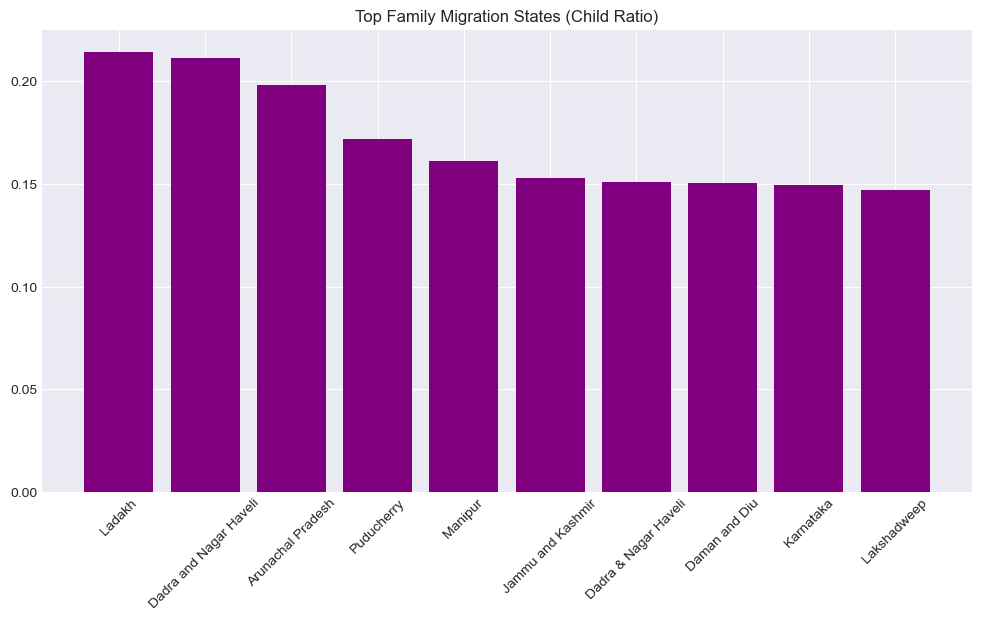

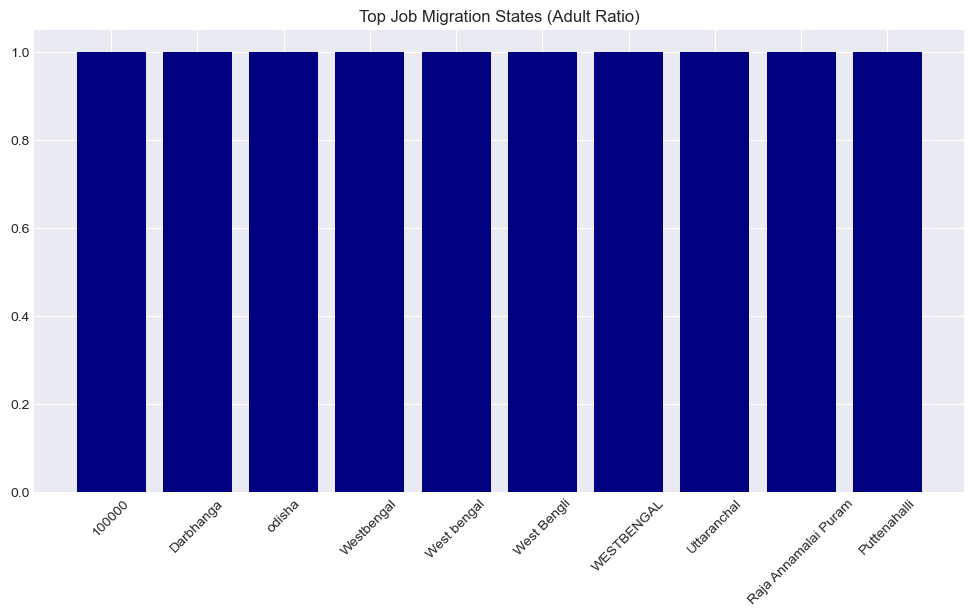

In [15]:
plt.figure(figsize=(12,6))
plt.bar(child_states['state'], child_states['child_ratio'], color='purple')
plt.xticks(rotation=45)
plt.title("Top Family Migration States (Child Ratio)")
plt.show()

plt.figure(figsize=(12,6))
plt.bar(adult_states['state'], adult_states['adult_ratio'], color='navy')
plt.xticks(rotation=45)
plt.title("Top Job Migration States (Adult Ratio)")
plt.show()


## 7. Seasonal Migration Pattern


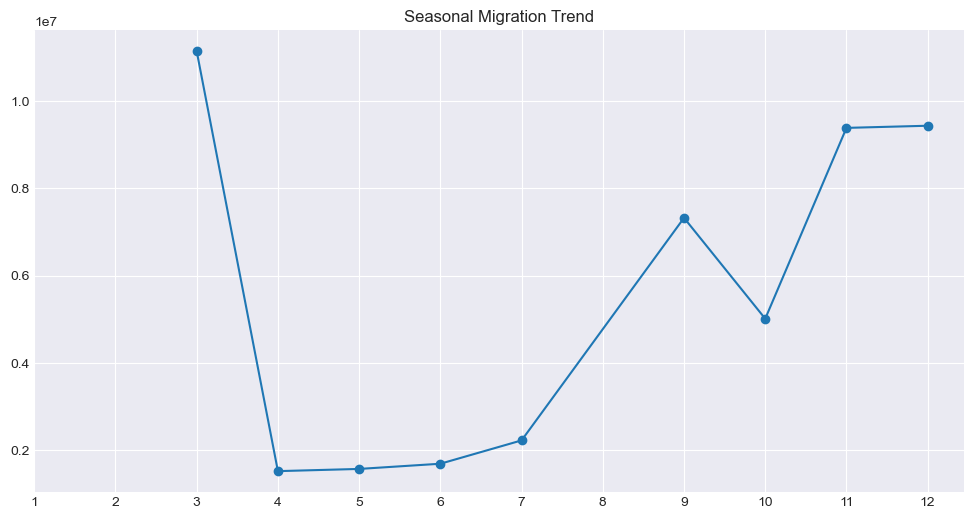

In [16]:
migration_df['month_num'] = migration_df['month'].dt.month
seasonality = migration_df.groupby('month_num')['total_demo'].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(seasonality['month_num'], seasonality['total_demo'], marker='o')
plt.xticks(range(1,13))
plt.title("Seasonal Migration Trend")
plt.show()


## 8. Forecasting Aadhaar Update Demand


14:17:01 - cmdstanpy - INFO - Chain [1] start processing
14:17:01 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Aryan\anaconda3\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


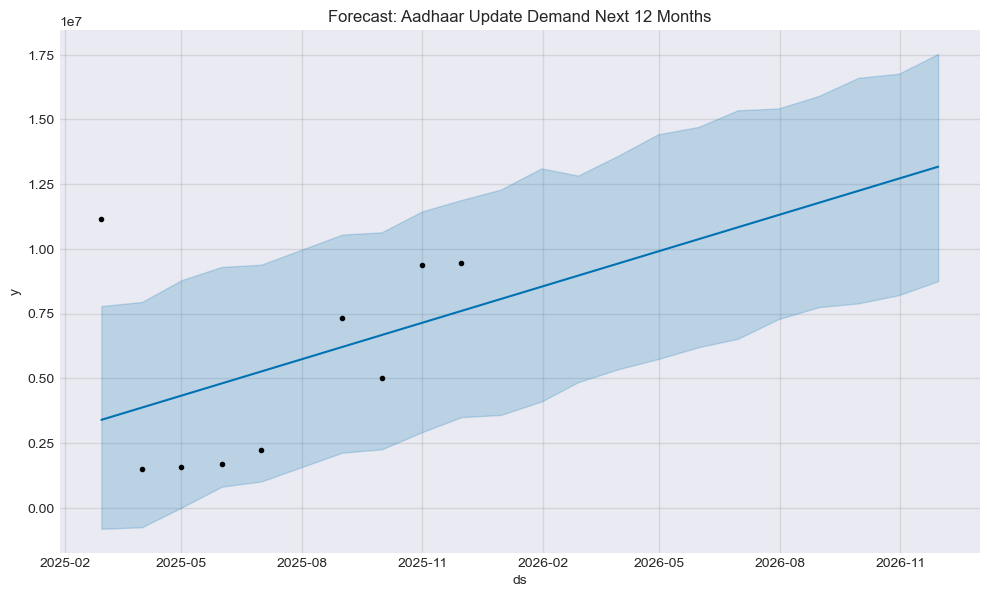

In [18]:
forecast_df = migration_df.groupby('month')['total_demo'].sum().reset_index()
forecast_df['month'] = forecast_df['month'].dt.to_timestamp()
forecast_df.columns = ['ds','y']

model = Prophet()
model.fit(forecast_df)
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

model.plot(forecast)
plt.title("Forecast: Aadhaar Update Demand Next 12 Months")
plt.show()


## 9. Recommendations
- Expand UIDAI update counters in Tamil Nadu, Jharkhand & top districts  
- Deploy mobile Aadhaar vans in NE sending states  
- Seasonal staffing during April–July migration peaks  
- Promote digital self-service update channels  


## 10. Limitations
- Aadhaar updates approximate migration, not exact  
- Local mobility within districts cannot be separated  
- Missing demographic attributes limits segmentation  


## 11. Future Work
- Add gender-based insights if data becomes available  
- Build district-to-district migration corridors  
- Compare with railway/bus ticket datasets  


## 12. Conclusion
Aadhaar demographic update data is a powerful proxy for internal migration.
This study shows receiving and sending states, hotspot districts,
family vs job-driven migration, seasonal peaks and future demand projection.
UIDAI can use this as a scalable planning tool for citizen service delivery.


In [19]:
pip install nbconvert pyppeteer


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for websockets: filename=websockets-10.4-cp312-cp312-win_amd64.whl size=95034 sha256=3d1f3b75fab51ac67af6e9fb77646a6e12c1a87a2656bf4c1c6224cfc2154471
  Stored in directory: c:\users\aryan\appdata\local\pip\cache\wheels\80\cf\6d\5d7e4c920cb41925a178b2d2621889c520d648bab487b1d7fd
Successfully built websockets
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.2.3
    Uninstalling urllib3-2.2.3:
      Successfully uninstalled urllib3-2.2.3
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.114 requires urllib3>=2.2.2, but you have urllib3 1.26.20 which is incompatible.
